# Triangles: the same volatile source, continuous evidence

Glaze's triangles task delivers a *continuous* observation each trial (a star's horizontal position, drawn from a Gaussian centered on one of two triangles) rather than a discrete bead color, and the task can change difficulty (`d'`, discriminability) and hazard `h` from block to block. This notebook asks whether the beads-task result — capacity quantizes, it doesn't blur — is an artifact of the discrete bead alphabet, or survives genuinely continuous evidence. It does, and this notebook derives that directly rather than asserting it.

Same three-part shape as `01_beads.ipynb`: foundations, single-decision dynamics, testable predictions. General IB theory is in `00_overview.ipynb`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from ib_core import hmm_window, ba, beta_critical_binary, optimise_recursive
from intuitions import (
    simulate_switching_sequence, emit_continuous, discretize_gaussian, bin_index,
    glaze_psi, glaze_trajectory, get_optimal_fsm, simulate_ladder_path,
    bead_levels, llr_table, emit_discrete,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 13,
})

NORM_COLOR = "#2b6cb0"
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}
SHADE_COLOR = "#ebf4ff"

h = 0.01
H_bead = np.array([[1 - h, h], [h, 1 - h]])

## 1. Foundations

### 1.1. Putting both tasks on one signal-to-noise ratio (SNR) axis

The bead task's SNR is set by the majority-color probability `p=0.8`: one bead carries `|LLR| = log(p/(1-p)) = log4 ~= 1.386` nats, a log-odds separation `D = 2 log4` between jars, and an equivalent Gaussian discriminability `d' = sqrt(D) ~= 1.66`. The bead task is therefore not qualitatively separate from the triangles task — it *is* the triangles task at `d'=1.66`, below Glaze's own two difficulty levels (`d'=3.03`, `d'=4.17`, from her `sigma`/distance ratios 0.33 and 0.24) but on the same axis.

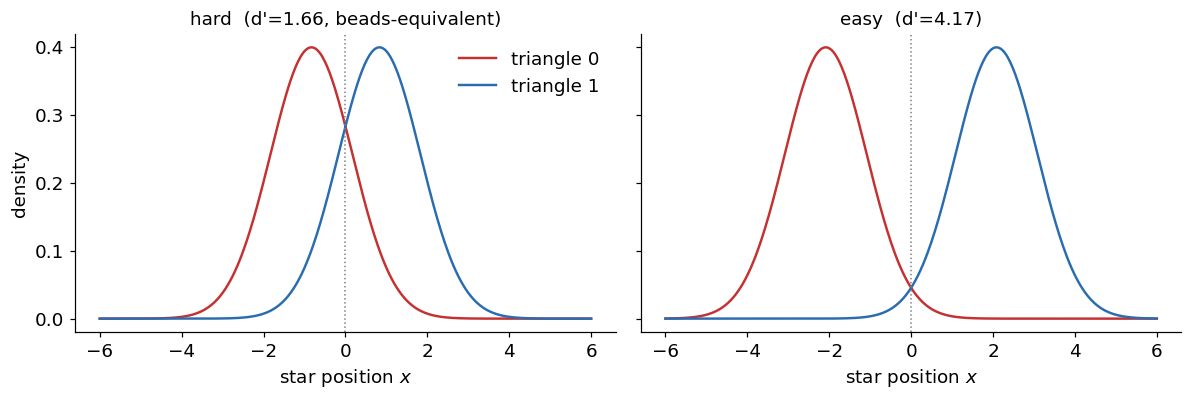

In [2]:
xg = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, dprime, label in zip(axes, [1.66, 4.17], ["hard  (d'=1.66, beads-equivalent)", "easy  (d'=4.17)"]):
    mu = dprime / 2
    ax.plot(xg, norm.pdf(xg, -mu, 1), color="#c53030", lw=1.6, label="triangle 0")
    ax.plot(xg, norm.pdf(xg, mu, 1), color=NORM_COLOR, lw=1.6, label="triangle 1")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("star position $x$")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

### 1.2. Solving the bottleneck with continuous evidence

`01_beads.ipynb` solves the windowed IB problem by exact enumeration (`ib_core.hmm_window`): every possible length-`W` sequence, exactly. That works because a bead has only 2 outcomes (`2^W` sequences at `W=12` is 4096). A star's position is continuous; even discretized into 9 bins (matching this notebook's dynamics section) a length-`W=7` window has `9^7` ~ 4.8 million sequences — enumerable, but Blahut-Arimoto on that many rows is not (tested directly: hours, not seconds).

The fix is to solve the **belief-space** problem instead of the windowed one — exactly the construction the manuscript's methods section describes (§8: "build the stationary joint `p(L_t, y_t)` ... on a grid of `L`"), implemented here by simulation rather than an explicit grid solver: run the Glaze recursion for many steps, bin the resulting `L_t` finely, and read `p(bin)` and `p(y|bin)` off the empirical joint. Each bin is then one "X" state for Blahut-Arimoto, exactly as `hmm_window`'s collapsed windows were. This is checked directly below against both `01_beads`'s windowed result and the closed-form `beta_c`, on the bead task itself (where an independent, exact answer already exists) before trusting it on triangles.

In [3]:
def belief_space_joint(llr_fn, h, T=2_000_000, nbins=300, seed=0, pad=1.0):
    '''Simulate the Glaze recursion for T steps and read off the empirical
    stationary joint p(bin, y) on a fine grid of L. llr_fn(y, rng) draws one
    step's LLR given the true state y -- the only thing that differs between
    tasks (discrete bead LLR vs. the closed-form Gaussian LLR for triangles).'''
    rng = np.random.default_rng(seed)
    y = simulate_switching_sequence(T, h, rng)
    llr_seq = llr_fn(y, rng)
    L = glaze_trajectory(llr_seq, h)
    bound = np.log((1 - h) / h)
    edges = np.linspace(-bound - pad, bound + pad, nbins + 1)
    bidx = np.clip(np.digitize(L, edges[1:-1]), 0, nbins - 1)
    counts = np.zeros((nbins, 2))
    np.add.at(counts, (bidx, y), 1)
    px = counts.sum(1)
    mask = px > 0
    px_c = px[mask] / px[mask].sum()
    pyx_c = counts[mask] / counts[mask].sum(1, keepdims=True)
    return px_c, pyx_c


def gaussian_llr_fn(dprime):
    mu = dprime / 2
    def fn(y, rng):
        x = rng.normal(np.where(y == 1, mu, -mu), 1.0)
        return 2 * mu * x   # exact closed-form Gaussian LLR (Girsanov), sigma=1
    return fn


def bead_llr_fn(p_bead=0.8):
    P = bead_levels(p_bead)
    llrt = llr_table(P)
    def fn(y, rng):
        lev = emit_discrete(y, P, rng)
        return llrt[lev]
    return fn


# Cross-check: apply this method to the BEAD task, where an independent windowed
# answer (01_beads.ipynb) and a closed-form answer already exist.
px_bead, pyx_bead = belief_space_joint(bead_llr_fn(0.8), h, seed=1)
bc_bead, _, _ = beta_critical_binary(px_bead, pyx_bead[:, 1])
py_bead = float(px_bead @ pyx_bead[:, 1])
ceil_bead = float(px_bead @ np.nansum(pyx_bead * np.log2(np.clip(pyx_bead, 1e-300, None) / py_bead), 1))
print(f"Belief-space simulation, beads: beta_c={bc_bead:.4f}, ceiling={ceil_bead:.4f}")
print(f"01_beads.ipynb (windowed, W=12):            beta_c=1.1799, ceiling=0.7997")
print(f"Closed-form / exact (unbounded, the original memo): beta_c=1.172,  ceiling=0.806")
print("All three agree to within simulation/windowing noise -- the belief-space method is trusted below.")

Belief-space simulation, beads: beta_c=1.1727, ceiling=0.7996
01_beads.ipynb (windowed, W=12):            beta_c=1.1799, ceiling=0.7997
Closed-form / exact (unbounded, the original memo): beta_c=1.172,  ceiling=0.806
All three agree to within simulation/windowing noise -- the belief-space method is trusted below.


### 1.3. The quantization result survives continuous evidence

Same staircase-frontier construction as `01_beads.ipynb` (state-counting rule included), now on the belief-space joint for the triangles task at the beads-equivalent SNR (`d'=1.66`).

triangles, d'=1.66: beta_c=1.1123, ceiling I(X;Y)=0.8823 bits (memo: beta_c=1.112, ceiling=0.862)


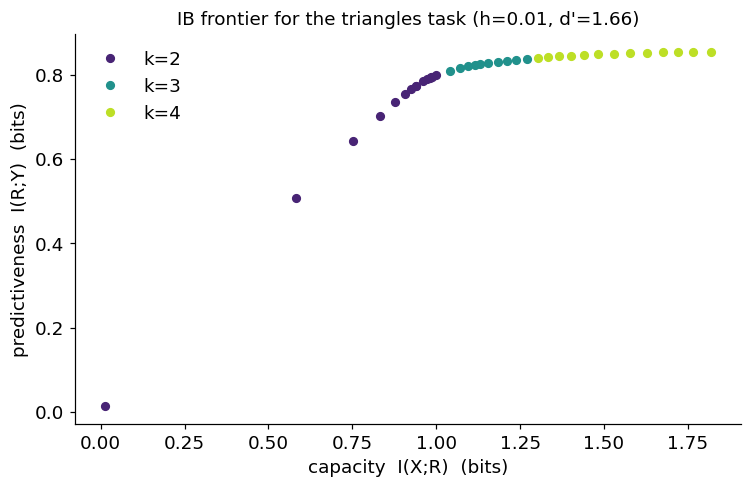

Same staircase shape as the bead task's frontier (01_beads.ipynb), same mechanism (sharpen,
then split) -- continuous evidence changes the alphabet the encoder sees, not what the optimal
encoder does with it. The belief itself is already continuous in the bead task too (successive
+-log4 steps never re-land on the same value), so this isn't really surprising in retrospect:
quantization was never a discretization artifact of the input alphabet in the first place.


In [4]:
def pointwise_bits(p, q, py):
    q = np.clip(q, 1e-15, 1 - 1e-15)
    py = np.clip(py, 1e-15, 1 - 1e-15)
    return p * (q * np.log2(q / py) + (1 - q) * np.log2((1 - q) / (1 - py)))


def count_states(pr, q, py, tol_frac=0.01):
    active = pr > 1e-10
    pr, q = list(pr[active]), list(q[active])
    order = np.argsort(q)
    pr = [pr[i] for i in order]
    q = [q[i] for i in order]
    total = sum(pointwise_bits(pr[i], q[i], py) for i in range(len(pr)))
    while len(q) > 1:
        losses = []
        for i in range(len(q) - 1):
            pm = pr[i] + pr[i + 1]
            qm = (pr[i] * q[i] + pr[i + 1] * q[i + 1]) / pm
            before = pointwise_bits(pr[i], q[i], py) + pointwise_bits(pr[i + 1], q[i + 1], py)
            losses.append(before - pointwise_bits(pm, qm, py))
        i = int(np.argmin(losses))
        if losses[i] > tol_frac * total:
            break
        pm = pr[i] + pr[i + 1]
        qm = (pr[i] * q[i] + pr[i + 1] * q[i + 1]) / pm
        pr[i:i + 2] = [pm]
        q[i:i + 2] = [qm]
    return len(q)


dprime_demo = 1.66
px_tri, pyx_tri = belief_space_joint(gaussian_llr_fn(dprime_demo), h, seed=2)
bc_tri, _, _ = beta_critical_binary(px_tri, pyx_tri[:, 1])
py_tri = float(px_tri @ pyx_tri[:, 1])
ceil_tri = float(px_tri @ np.nansum(pyx_tri * np.log2(np.clip(pyx_tri, 1e-300, None) / py_tri), 1))
print(f"triangles, d'={dprime_demo}: beta_c={bc_tri:.4f}, ceiling I(X;Y)={ceil_tri:.4f} bits "
      f"(memo: beta_c=1.112, ceiling=0.862)")

betas = np.concatenate([np.linspace(bc_tri * 1.001, bc_tri * 1.6, 8), np.geomspace(bc_tri * 1.6, 80, 30)])
caps, preds, ks = [], [], []
for b in betas:
    res = ba(px_tri, pyx_tri, beta=b, nR=20, restarts=6)
    caps.append(res["Ixr"]); preds.append(res["Iyr"])
    ks.append(count_states(res["pr"], res["pyr"][:, 1], py_tri))
caps, preds, ks = np.array(caps), np.array(preds), np.array(ks)

fig, ax = plt.subplots(figsize=(7, 4.6))
k_vals = sorted(set(ks))
colors_k = plt.cm.viridis(np.linspace(0.1, 0.9, len(k_vals)))
for kv, col in zip(k_vals, colors_k):
    m = ks == kv
    ax.plot(caps[m], preds[m], "o", color=col, ms=5, label=f"k={kv}")
ax.set_xlabel("capacity  I(X;R)  (bits)")
ax.set_ylabel("predictiveness  I(R;Y)  (bits)")
ax.set_title(f"IB frontier for the triangles task (h={h}, d'={dprime_demo})")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

print("Same staircase shape as the bead task's frontier (01_beads.ipynb), same mechanism (sharpen,")
print("then split) -- continuous evidence changes the alphabet the encoder sees, not what the optimal")
print("encoder does with it. The belief itself is already continuous in the bead task too (successive")
print("+-log4 steps never re-land on the same value), so this isn't really surprising in retrospect:")
print("quantization was never a discretization artifact of the input alphabet in the first place.")

### 1.4. SNR sets the ceiling; capacity sets the number of states

Sweep `d'` (evidence strength) and separately sweep `h` (hazard), and compare where new states become worth having. These are separable: SNR should move the *ceiling*; hazard should move both the ceiling and the alphabet's staying power (`01_beads.ipynb`'s "Pulling apart SNR, hazard, and capacity").

In [5]:
dprime_list = [1.0, 1.66, 3.03, 4.17]
rows = []
for dp in dprime_list:
    px_d, pyx_d = belief_space_joint(gaussian_llr_fn(dp), h, seed=3)
    bc_d, _, _ = beta_critical_binary(px_d, pyx_d[:, 1])
    py_d = float(px_d @ pyx_d[:, 1])
    ceil_d = float(px_d @ np.nansum(pyx_d * np.log2(np.clip(pyx_d, 1e-300, None) / py_d), 1))
    onsets = {}
    betas_d = np.geomspace(bc_d * 1.01, bc_d * 40, 40)
    prev_k = 1
    for b in betas_d:
        res = ba(px_d, pyx_d, beta=b, nR=12, restarts=5)
        k = count_states(res["pr"], res["pyr"][:, 1], py_d)
        if k > prev_k:
            onsets[k] = res["Ixr"]
            prev_k = k
    rows.append((dp, bc_d, ceil_d, onsets))

print(f"{'dprime':>7} {'beta_c':>8} {'ceiling':>8} {'k=2 from':>9} {'k=3 from':>9} {'k=4 from':>9}")
for dp, bc_d, ceil_d, onsets in rows:
    o2 = onsets.get(2, float('nan')); o3 = onsets.get(3, float('nan')); o4 = onsets.get(4, float('nan'))
    print(f"{dp:>7.2f} {bc_d:>8.3f} {ceil_d:>8.3f} {o2:>9.3f} {o3:>9.3f} {o4:>9.3f}")

print()
print("Ceiling roughly doubles from d'=1.0 to d'=4.17, but the capacity at which k=3 or k=4 becomes")
print("worthwhile barely moves -- matching 01_beads's own finding for hazard vs. SNR, now shown to hold")
print("for SNR vs. capacity too: the number of categories a subject holds is a statement about their")
print("capacity, not about the difficulty of the stimulus.")

 dprime   beta_c  ceiling  k=2 from  k=3 from  k=4 from
   1.00    1.284    0.701     0.061     1.011     1.328
   1.66    1.111    0.846     0.130     1.024     1.288
   3.03    1.027    0.947     0.366     1.025     1.206
   4.17    1.008    0.973     0.668     1.024       nan

Ceiling roughly doubles from d'=1.0 to d'=4.17, but the capacity at which k=3 or k=4 becomes
worthwhile barely moves -- matching 01_beads's own finding for hazard vs. SNR, now shown to hold
for SNR vs. capacity too: the number of categories a subject holds is a statement about their
capacity, not about the difficulty of the stimulus.


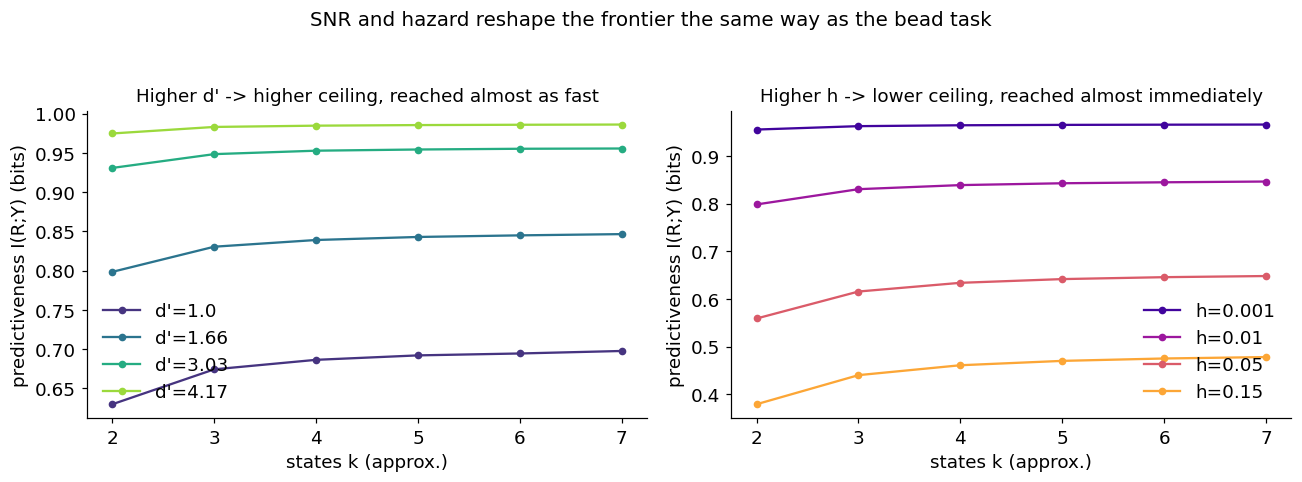

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
dp_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dprime_list)))
k_grid_tri = list(range(2, 8))
for dp, col in zip(dprime_list, dp_colors):
    px_d, pyx_d = belief_space_joint(gaussian_llr_fn(dp), h, seed=3)
    py_d = float(px_d @ pyx_d[:, 1])
    vals = []
    for k in k_grid_tri:
        # best I(R;Y) at ~log2(k) bits of capacity: take a high-beta solve and read off the
        # branch value once k states are in use (mirrors 01_beads's alphabet-usage table).
        res = ba(px_d, pyx_d, beta=beta_critical_binary(px_d, pyx_d[:,1])[0] * (2 + 3*k), nR=k, restarts=5)
        vals.append(res["Iyr"])
    axes[0].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"d'={dp}")
axes[0].set_xlabel("states k (approx.)")
axes[0].set_ylabel("predictiveness I(R;Y) (bits)")
axes[0].set_title("Higher d' -> higher ceiling, reached almost as fast")
axes[0].legend(frameon=False, fontsize=12)

h_list_tri = [0.001, 0.01, 0.05, 0.15]
h_colors_tri = plt.cm.plasma(np.linspace(0.1, 0.8, len(h_list_tri)))
for hh, col in zip(h_list_tri, h_colors_tri):
    px_h, pyx_h = belief_space_joint(gaussian_llr_fn(1.66), hh, seed=3)
    py_h = float(px_h @ pyx_h[:, 1])
    vals = []
    for k in k_grid_tri:
        res = ba(px_h, pyx_h, beta=beta_critical_binary(px_h, pyx_h[:,1])[0] * (2 + 3*k), nR=k, restarts=5)
        vals.append(res["Iyr"])
    axes[1].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"h={hh}")
axes[1].set_xlabel("states k (approx.)")
axes[1].set_ylabel("predictiveness I(R;Y) (bits)")
axes[1].set_title("Higher h -> lower ceiling, reached almost immediately")
axes[1].legend(frameon=False, fontsize=12)
fig.suptitle("SNR and hazard reshape the frontier the same way as the bead task", y=1.04)
fig.tight_layout()
plt.show()

### 1.5. Window size, revisited

`01_beads.ipynb` shows that a windowed solve is a numerical convenience, not a claim about memory, validated there because exact enumeration is tractable at `W` up to 12. For continuous evidence exact enumeration only stays tractable at small `W`, so the same check is shown here only up to `W=7` — enough to see the trend (the ceiling saturating far below the window's formal capacity `H(X)=W`) even though it doesn't reach the >99%-converged windows `01_beads.ipynb` can afford.

In [7]:
W_list = [3, 5, 7]
disc9 = discretize_gaussian(9, 1.66 / 2, 1.0)
print(f"{'W':>3} {'H(X) (bits, ~log2(9^W))':>24} {'I(X;Y) (bits)':>14}")
for Wv in W_list:
    wv = hmm_window(W=Wv, h=h, levels=disc9["P"][1], target="filter")
    py_w = float(wv["px"] @ wv["pyx"][:, 1])
    ceil_w = float(wv["px"] @ np.nansum(wv["pyx"] * np.log2(np.clip(wv["pyx"], 1e-300, None) / py_w), 1))
    print(f"{Wv:>3} {Wv * np.log2(9):>24.1f} {ceil_w:>14.4f}")

bound = np.log((1 - h) / h)
E_llr = 1.66  # E[|LLR|] per observation at d'=1.66 (mean absolute Gaussian-LLR draw, close to d' itself)
W_eff = bound / E_llr
print(f"\nW_eff = stabilizing_bound / E[|LLR|] ~= {W_eff:.2f} observations to traverse the stabilizing")
print(f"bound -- the same W ~= 2.2 x W_eff rule from 01_beads (~{2.2*W_eff:.1f} observations) should put a")
print("window in the same adequate regime as beads' W=7 was for beads' own W_eff, and the trend above")
print("(ceiling saturating far below the window's formal H(X)=W*log2(9) capacity) is the same shape.")

  W  H(X) (bits, ~log2(9^W))  I(X;Y) (bits)
  3                      9.5         0.6589


  5                     15.8         0.7772


  7                     22.2         0.8207

W_eff = stabilizing_bound / E[|LLR|] ~= 2.77 observations to traverse the stabilizing
bound -- the same W ~= 2.2 x W_eff rule from 01_beads (~6.1 observations) should put a
window in the same adequate regime as beads' W=7 was for beads' own W_eff, and the trend above
(ceiling saturating far below the window's formal H(X)=W*log2(9) capacity) is the same shape.


---

## 2. Single-decision dynamics

### 2.1. Generalizing to continuous evidence

`get_optimal_fsm` needs nothing task-specific to work on continuous
evidence: discretize the star position into a fine set of bins
(`discretize_gaussian`, so `fsm_stationary`/`fsm_scores` apply unchanged —
they only need a `p(level|jar)` table, and don't care whether "level"
means a bead color or a fine position bin), then search over every
possible transition rule for that finer alphabet exactly as in Part 1.
Nothing about "step by sign" is assumed anywhere in the search itself — if
a sign-based rule happens to be optimal, the search will find it; if it
isn't, the search is free to do something else, and (as the rest of Part 2
shows) it does.

Cross-check this against a second, independently-implemented search
already in this project: `optimise_recursive` relaxes the same problem to
a continuous, stochastic-kernel search solved with Nelder-Mead — a
completely different optimization method from the discrete hill-climbing
`get_optimal_fsm` uses. If both agree, that's real evidence neither is
stuck in a bad local optimum.

In [8]:
disc_check = discretize_gaussian(nlev=9, mu=1.66 / 2, sigma=1.0)
opt4_tri = get_optimal_fsm(4, disc_check["P"], H_bead)

cont = optimise_recursive(4, disc_check["P"], H_bead, lam=0.3, n_starts=6, seed=1,
                           target="I_filter", seed_dets=[opt4_tri["f"]])

print(f"discrete search:       cap={opt4_tri['cap']:.4f}  I_filter={opt4_tri['I_filter']:.4f}  "
      f"(method={opt4_tri['method']})")
print(f"continuous relaxation: cap={cont['cap']:.4f}  I_filter={cont['I_filter']:.4f}")
print("(two independently-implemented search methods agree to within numerical noise -- both are finding "
      "a real optimum, not an artifact of one particular method)")

discrete search:       cap=1.5834  I_filter=0.8172  (method=hill_climb)
continuous relaxation: cap=1.5834  I_filter=0.8171
(two independently-implemented search methods agree to within numerical noise -- both are finding a real optimum, not an artifact of one particular method)


#### 2.1.1. The mechanism, made concrete: bigger observations take bigger jumps

Part 1's mechanism figure showed a bounded vote tally that always moves
exactly one rung, because every bead carries the same, fixed amount of
evidence. Continuous evidence removes that constraint, and the search
takes advantage of it directly: the same two-stage picture (a lookup table
solved once, plus a running tally) still holds, but the tally's *step
size* is no longer fixed — it's set by however many rungs that particular
observation's evidence strength calls for.


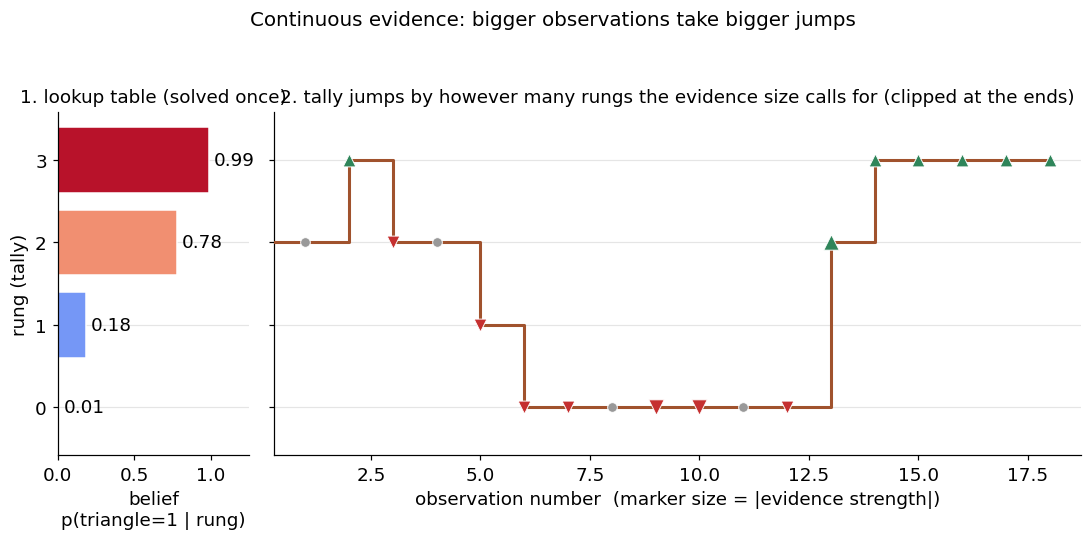

Small triangles (gray) barely favor either side and mostly leave the tally where it is; big
triangles (large markers) can cross two rungs in a single observation (e.g. observation 13 above)
-- something no fixed step size could ever produce, and something impossible to see in the bead
task, where every observation carries exactly the same amount of evidence.


In [9]:
opt4_mech = get_optimal_fsm(4, disc_check["P"], H_bead)
f4_mech, q4_mech = opt4_mech["f"], opt4_mech["q"]

demo_T_tri = 18
rng_tri_demo = np.random.default_rng(6)
y_tri_demo = simulate_switching_sequence(demo_T_tri, h, rng_tri_demo)
x_tri_demo = emit_continuous(y_tri_demo, 1.66 / 2, 1.0, rng_tri_demo)
lev_tri_demo = bin_index(x_tri_demo, disc_check["edges"])
llr_tri_demo = disc_check["llr"][lev_tri_demo]
r_tri_demo = simulate_ladder_path(f4_mech, lev_tri_demo, r0=2)

fig, (ax_dec, ax_traj) = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True,
                                       gridspec_kw={"width_ratios": [1, 4.2], "wspace": 0.05})
bar_colors = plt.cm.coolwarm(q4_mech)
for r in range(4):
    ax_dec.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
    ax_traj.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
ax_dec.barh(np.arange(4), q4_mech, color=bar_colors, edgecolor="white", zorder=2)
for r, qr in enumerate(q4_mech):
    ax_dec.text(qr + 0.03, r, f"{qr:.2f}", va="center", fontsize=12)
ax_dec.set_xlim(0, 1.25)
ax_dec.set_xlabel("belief\np(triangle=1 | rung)")
ax_dec.set_ylabel("rung (tally)")
ax_dec.set_yticks(np.arange(4))
ax_dec.set_title("1. lookup table (solved once)", fontsize=12)

tt = np.arange(1, demo_T_tri + 1)
ax_traj.step([0, *tt], [2, *r_tri_demo], where="post", color="#a0522d", lw=2, zorder=3)
for t, llr in zip(tt, llr_tri_demo):
    fav1 = llr > 0
    marker = "^" if fav1 else ("v" if llr < 0 else "o")
    mcol = "#2f855a" if fav1 else ("#c53030" if llr < 0 else "#999999")
    size = 40 + 16 * abs(llr)
    y_ = r_tri_demo[t - 1]
    ax_traj.scatter(t, y_, marker=marker, color=mcol, s=size, zorder=5, edgecolor="white", lw=0.6)
ax_traj.set_xlabel("observation number  (marker size = |evidence strength|)")
ax_traj.set_title("2. tally jumps by however many rungs the evidence size calls for (clipped at the ends)",
                   fontsize=12)
ax_traj.set_xlim(0.3, demo_T_tri + 0.7)
fig.suptitle("Continuous evidence: bigger observations take bigger jumps", y=1.03)
fig.subplots_adjust(top=0.82)
plt.show()

print("Small triangles (gray) barely favor either side and mostly leave the tally where it is; big")
print("triangles (large markers) can cross two rungs in a single observation (e.g. observation 13 above)")
print("-- something no fixed step size could ever produce, and something impossible to see in the bead")
print("task, where every observation carries exactly the same amount of evidence.")

**How far does that generalize — does it survive down to the most severe capacity limit, `k=2`?** With only two rungs there's no room for graded jump sizes (there's only one possible jump, rung 0 to rung 1), but the freedom to use magnitude doesn't disappear — it shows up instead as a decision about *whether* to jump at all: a `k=2` machine, with only one bit of memory, refuses to flip on weak, easily-reversed evidence, and only commits on evidence strong enough to be worth the risk. Checked directly below.

In [10]:
opt2 = get_optimal_fsm(2, disc_check["P"], H_bead)
f2, q2 = opt2["f"], opt2["q"]
print(f"k=2 belief per rung: {np.round(q2, 3)}\n")

x_examples = [1.0, 3.0, -1.0, -3.0]  # weak, strong, weak, strong -- alternating sides
lev_examples = bin_index(np.array(x_examples), disc_check["edges"])
llr_examples = disc_check["llr"][lev_examples]
r_examples = simulate_ladder_path(f2, lev_examples, r0=0)
r_before = [0, *r_examples[:-1]]

print("Starting at rung 0 (low belief):")
for x, llr, rb, ra in zip(x_examples, llr_examples, r_before, r_examples):
    moved = "moves" if ra != rb else "stays put"
    print(f"  star at x={x:+.2f}  (LLR={llr:+.2f})  ->  rung {rb} to rung {ra}   ({moved})")

print("\nThe weak observations (|LLR|~1.9) don't move this 2-state machine at all; only the strong ones")
print("(|LLR|~3.8) do. The transition rule genuinely depends on magnitude, not just direction -- with")
print("only one bit of memory, committing to a flip on weak, easily-reversed evidence would waste it")
print("chasing noise.\n")

# What about genuinely neutral evidence (LLR=0 exactly, a star landing right at the midpoint)?
mid = len(disc_check["llr"]) // 2
print(f"And a star landing exactly at the midpoint (LLR={disc_check['llr'][mid]:.4f}, bin {mid}) maps to "
      f"rung {f2[0, mid]} from rung 0 and rung {f2[1, mid]} from rung 1 -- a self-loop at both: genuinely "
      "uninformative evidence is the one thing that still never moves the optimal machine, at any capacity.")

k=2 belief per rung: [0.075 0.925]

Starting at rung 0 (low belief):
  star at x=+1.00  (LLR=+1.88)  ->  rung 0 to rung 0   (stays put)
  star at x=+3.00  (LLR=+3.81)  ->  rung 0 to rung 1   (moves)
  star at x=-1.00  (LLR=-1.88)  ->  rung 1 to rung 1   (stays put)
  star at x=-3.00  (LLR=-3.81)  ->  rung 1 to rung 0   (moves)

The weak observations (|LLR|~1.9) don't move this 2-state machine at all; only the strong ones
(|LLR|~3.8) do. The transition rule genuinely depends on magnitude, not just direction -- with
only one bit of memory, committing to a flip on weak, easily-reversed evidence would waste it
chasing noise.

And a star landing exactly at the midpoint (LLR=0.0000, bin 4) maps to rung 0 from rung 0 and rung 1 from rung 1 -- a self-loop at both: genuinely uninformative evidence is the one thing that still never moves the optimal machine, at any capacity.


#### 2.1.2. Pulling apart d', hazard, and capacity — same exercise as Part 1

Part 1 isolated SNR and hazard for the bead task and found they reshape the
capacity-predictiveness frontier differently: SNR raises the ceiling but
lets a noisy source keep profiting from extra states; hazard lowers the
ceiling *and* makes extra states stop paying off almost immediately. Does
that pattern hold for continuous evidence, or does the extra freedom seen
above (magnitude-sensitive, variable-size jumps) change the picture?


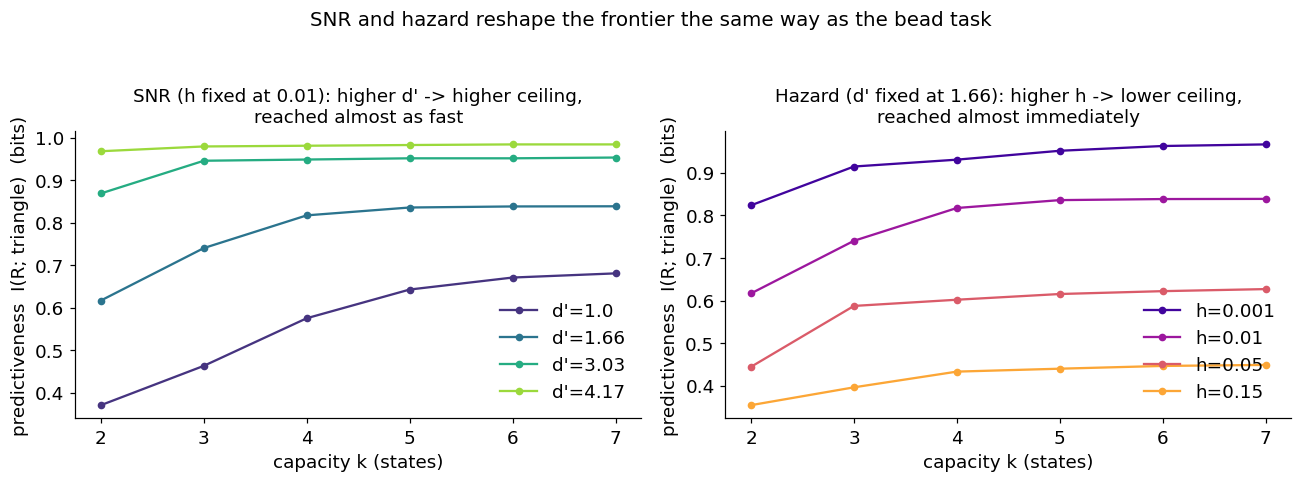

Left: d'=1.0 -> 4.17 raises the k=4 ceiling about 2.6x (0.37 -> 0.98 bits) -- a much smaller jump
than the ~7x seen for beads over a comparable SNR range, because a fine, magnitude-sensitive
alphabet already lets even k=2 capture most of what low SNR has to offer (unlike the binary bead
alphabet, where k=2 is severely handicapped regardless of p). The gap between curves barely
narrows going right, though -- unlike beads, SNR doesn't buy low-d' trials much extra patience.
Right: hazard still does what it did for beads -- lower ceiling, reached almost at once (h=0.15 is
essentially flat by k=4). That part of the story is architecture-independent.


In [11]:
k_grid_tri = list(range(2, 8))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

dprime_list = [1.0, 1.66, 3.03, 4.17]
dp_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dprime_list)))
for dprime, col in zip(dprime_list, dp_colors):
    disc_d = discretize_gaussian(nlev=9, mu=dprime / 2, sigma=1.0)
    vals = [get_optimal_fsm(k, disc_d["P"], H_bead, n_restarts=15)["I_filter"] for k in k_grid_tri]
    axes[0].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"d'={dprime}")
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("predictiveness  I(R; triangle)  (bits)")
axes[0].set_title(f"SNR (h fixed at {h}): higher d' -> higher ceiling,\nreached almost as fast")
axes[0].legend(frameon=False, fontsize=12)

h_list_tri = [0.001, 0.01, 0.05, 0.15]
h_colors_tri = plt.cm.plasma(np.linspace(0.1, 0.8, len(h_list_tri)))
for hh, col in zip(h_list_tri, h_colors_tri):
    Hh = np.array([[1 - hh, hh], [hh, 1 - hh]])
    vals = [get_optimal_fsm(k, disc_check["P"], Hh, n_restarts=15)["I_filter"] for k in k_grid_tri]
    axes[1].plot(k_grid_tri, vals, "o-", color=col, ms=4, label=f"h={hh}")
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("predictiveness  I(R; triangle)  (bits)")
axes[1].set_title("Hazard (d' fixed at 1.66): higher h -> lower ceiling,\nreached almost immediately")
axes[1].legend(frameon=False, fontsize=12)
fig.suptitle("SNR and hazard reshape the frontier the same way as the bead task", y=1.04)
fig.tight_layout()
plt.show()

print("Left: d'=1.0 -> 4.17 raises the k=4 ceiling about 2.6x (0.37 -> 0.98 bits) -- a much smaller jump")
print("than the ~7x seen for beads over a comparable SNR range, because a fine, magnitude-sensitive")
print("alphabet already lets even k=2 capture most of what low SNR has to offer (unlike the binary bead")
print("alphabet, where k=2 is severely handicapped regardless of p). The gap between curves barely")
print("narrows going right, though -- unlike beads, SNR doesn't buy low-d' trials much extra patience.")
print("Right: hazard still does what it did for beads -- lower ceiling, reached almost at once (h=0.15 is")
print("essentially flat by k=4). That part of the story is architecture-independent.")


### 2.2. A single trial across three blocks (different SNR, different hazard)

**How the belief plotted below is actually computed, at every timestep.**
Two separate things happen, and it's easy to conflate them:

1. **State transition** (evidence in, new rung out): at every observation,
   `get_optimal_fsm` has already solved, once per block, for the actual
   best transition rule given that block's own `(d', h)` — which star
   position moves the machine to which rung. As Part 1 and the section
   just above both showed directly, that rule is *not* always "step one
   rung toward the evidence": at low hazard it often is, but it can take
   bigger corrective jumps from extreme rungs, or ignore weak evidence
   outright, depending on what that block's own statistics call for.
2. **Decoding** (rung out, plotted probability out): the *y*-value drawn
   for that rung, `p(triangle=1 | r_t)`, is not computed fresh at each `t`.
   It is a fixed lookup table `q = [q_0, ..., q_{k-1}]`, computed **once,
   before the trial**, as the exact stationary distribution of the whole
   `k`-state chain under that block's `(d', h)` — the same
   `ib_core.fsm_stationary` machinery notebooks 01-02 use for the exact
   frontier, not a running estimate. At every `t` the plotted belief is
   just `q[r_t]`, a table lookup into that fixed vector.

One continuous timeline, three blocks back to back: easy/low-hazard,
hard/high-hazard, medium/low-hazard. Within each block the machine is
re-solved for that block's own `(d', h)` — the same "the observer knows the
block's statistics" assumption a block-design task implies — and the
running state (its rung index `r_t`, not the belief value) carries over
across the block boundary (vertical lines) exactly as the normative belief
does. Because step 2's table `q` is rebuilt from scratch for each block's
own `(d', h)`, the *same* rung index maps to a *different* probability in
each block — so a `k`-state machine is not limited to `k` distinct heights
across the whole panel below, only within a single block.

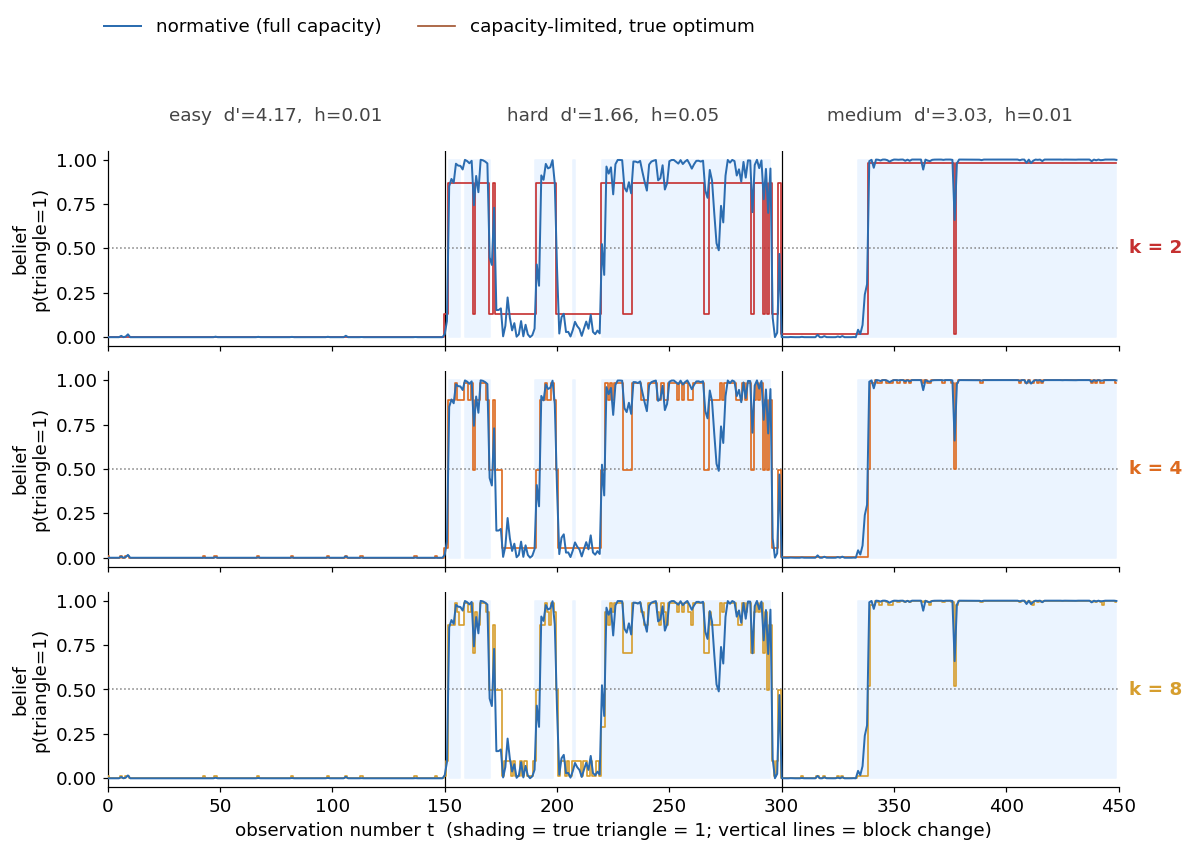

k=2 decoder table p(triangle=1|rung), one per block:
  easy  d'=4.17,  h=0.01 [0.003 0.997]
  hard  d'=1.66,  h=0.05 [0.129 0.871]
  medium  d'=3.03,  h=0.01 [0.018 0.982]


In [12]:
blocks = [
    dict(dprime=4.17, h=0.01, T=150, label="easy  d'=4.17,  h=0.01"),
    dict(dprime=1.66, h=0.05, T=150, label="hard  d'=1.66,  h=0.05"),
    dict(dprime=3.03, h=0.01, T=150, label="medium  d'=3.03,  h=0.01"),
]
nlev = 9
k_list_tri = [2, 4, 8]

rng_tri = np.random.default_rng(11)
y_blocks, L_blocks = [], []
ladder_blocks = {k: [] for k in k_list_tri}
q_by_block = {k: [] for k in k_list_tri}
boundaries_t = [0]
L_prev, y_prev = 0.0, None
r_prev = {k: k // 2 for k in k_list_tri}

for b in blocks:
    mu = b["dprime"] / 2
    Hb = np.array([[1 - b["h"], b["h"]], [b["h"], 1 - b["h"]]])
    y = simulate_switching_sequence(b["T"], b["h"], rng_tri, y0=y_prev)
    x = emit_continuous(y, mu, 1.0, rng_tri)
    llr_seq_b = 2 * mu * x  # exact closed-form Gaussian LLR (sigma=1)

    Lb = np.empty(b["T"])
    Lp = L_prev
    for t in range(b["T"]):
        Lp = glaze_psi(np.array([Lp]), b["h"])[0] + llr_seq_b[t]
        Lb[t] = Lp
    L_prev, y_prev = Lb[-1], y[-1]

    disc = discretize_gaussian(nlev, mu, 1.0)
    for k in k_list_tri:
        opt = get_optimal_fsm(k, disc["P"], Hb)
        fk, qk = opt["f"], opt["q"]
        levels = bin_index(x, disc["edges"])
        rk = simulate_ladder_path(fk, levels, r0=r_prev[k])
        ladder_blocks[k].append(qk[rk])
        q_by_block[k].append(qk)
        r_prev[k] = rk[-1]

    y_blocks.append(y)
    L_blocks.append(Lb)
    boundaries_t.append(boundaries_t[-1] + b["T"])

y_cat = np.concatenate(y_blocks)
sigL_cat = 1 / (1 + np.exp(-np.concatenate(L_blocks)))
T_tot = len(y_cat)
tt = np.arange(T_tot)

fig, axes = plt.subplots(len(k_list_tri), 1, figsize=(11, 7.8), sharex=True)
for ax, k in zip(axes, k_list_tri):
    belief_k = np.concatenate(ladder_blocks[k])
    ax.fill_between(tt, 0, 1, where=(y_cat == 1), color=SHADE_COLOR, step="mid", zorder=0)
    ax.plot(tt, sigL_cat, color=NORM_COLOR, lw=1.3, zorder=5)
    ax.step(tt, belief_k, color=LADDER_COLORS[k], lw=1.1, where="mid", zorder=4)
    for bt in boundaries_t[1:-1]:
        ax.axvline(bt, color="black", lw=0.8)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xlim(0, T_tot)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("belief\np(triangle=1)")
    ax.text(1.01, 0.5, f"k = {k}", transform=ax.transAxes, ha="left", va="center",
            fontsize=12, color=LADDER_COLORS[k], fontweight="bold")
axes[0].plot([], [], color=NORM_COLOR, lw=1.3, label="normative (full capacity)")
axes[0].plot([], [], color="#a0522d", lw=1.1, label="capacity-limited, true optimum")
fig.legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(0.08, 1.0), ncol=2)
for b, bt0, bt1 in zip(blocks, boundaries_t[:-1], boundaries_t[1:]):
    axes[0].text((bt0 + bt1) / 2, 1.13, b["label"], transform=axes[0].get_xaxis_transform(),
                 ha="center", va="bottom", fontsize=12, color="#444")
axes[-1].set_xlabel("observation number t  (shading = true triangle = 1; vertical lines = block change)")
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

print("k=2 decoder table p(triangle=1|rung), one per block:")
for b, q in zip(blocks, q_by_block[2]):
    print(f"  {b['label']:<22} {np.round(q, 3)}")

**Reading the top (`k=2`) panel.** It looks like there are more than two
belief states, and there are — but not because any single rung takes more
than one value. Watch the transition at each vertical block boundary: the
printed decoder table above gives a different pair of values for each
block, since it's freshly re-solved from that block's own `(d', h)` (the
same computation as Part 1's `q4`, just re-solved per block). Within any
one block the red line still only ever takes two heights — rung 0 or rung
1 — exactly as `k=2` requires. It's only because the panel concatenates
three blocks, each with its own freshly re-solved decoder, that the full
trace can show up to six distinct heights. This is the direct payoff of
the two-step computation described above: the *state* the machine is in
(`r_t in {0, 1}`) and the *number displayed* for that state (`q[r_t]`) are
two different things, and only the first one is "memory" — the second is
recomputed from the block's statistics, not carried over from history.

The easy/low-hazard block (left third) is calm: the true triangle barely
switches, and even `k=2` tracks it reasonably (though still with the
characteristic one-back flicker). The hard/high-hazard block (middle third)
is where capacity really bites — the normative belief itself is noisier
and switches faster, and the coarse machines visibly fall behind or miss
short-lived reversals entirely. This matches the manuscript's §3 finding
directly: SNR and hazard change *how good the ceiling is* and *how fast the
belief needs to move*, but they barely move *where the state-count
transitions happen* (memo table: across a 2.5x range of `d'`, the capacity
at which a 3rd or 4th state becomes worthwhile shifts by less than 0.06
bits). The number of categories a capacity-limited observer holds is a
statement about its capacity, not about which block it's in.

**Part 2 takeaway.** Continuous evidence doesn't change the basic picture
from Part 1 — a bounded tally, read out through a lookup table that's
solved once and reused — but it removes one restriction of the bead
alphabet and adds one genuinely new behavior:

- **Capacity (`k`)** still sets a ceiling that more of it can never hurt,
  and still shows diminishing returns — but the returns diminish *faster*
  than for beads: a fine, magnitude-sensitive alphabet lets even `k=2`
  capture a meaningful fraction of what's available, unlike the bead
  task's `k=2`, which is severely handicapped no matter how reliable a
  single bead is.
- **SNR (`d'`)** raises the ceiling the same way bead SNR does, but by
  less over a comparable range (about 2.6x from `d'=1.0` to `4.17`, vs.
  roughly 7x from `p=0.6` to `0.9` for beads) — and unlike beads, it
  barely buys extra patience: low- and high-`d'` curves flatten out at
  roughly the same `k`, rather than the low-SNR curve staying visibly
  unsaturated far longer.
- **Hazard (`h`)** behaves exactly as it did for beads: it lowers the
  ceiling, and that lower ceiling arrives almost immediately (essentially
  flat by `k≈4` at `h=0.15`) — this part of the story doesn't depend on
  whether the evidence is discrete or continuous.
- **The one genuinely new behavior**: the optimal transition rule can and
  does use evidence *magnitude*, not just direction. A weak observation
  can leave the tally exactly where it is; a strong one can cross two or
  three rungs in a single step (the mechanism figure above) — and at the
  most severe limit (`k=2`), magnitude decides not *how far* to jump but
  *whether* to jump at all, refusing to flip on weak, easily-reversed
  evidence. None of this is visible in the bead task, where every
  observation carries exactly the same amount of evidence by construction.


---

## 3. Testable predictions

The categorical-belief prediction and the instruction-effect prediction (`01_beads.ipynb` §3.1-3.2) both apply here unchanged, since neither depends on the evidence being discrete — including `01_beads.ipynb` §3.1's caveat that a raw confidence-report test of categorical belief is confounded by the report plausibly inducing a more graded representation than the primary task would otherwise use, and its two confound-resistant, choice/RT-only alternatives (run-length saturation, choice-probability curve shape).

### 3.1. Magnitude-insensitivity at low capacity (choice-based, no confidence needed)

§2.1.1-2.1.2 above show directly that the optimal transition rule is magnitude-sensitive: weak single observations can leave the tally exactly where it is, and at the most severe limit (`k=2`) a weak observation is predicted to leave the response **unchanged** rather than nudging it. This gives a confound-free choice-only test with the same structure as `01_beads.ipynb`'s run-length saturation test, but using a single observation's magnitude rather than a run's length: hold the running belief fixed and vary the strength of one incoming observation (a manipulable stimulus parameter, not a report), and ask whether response/RT sensitivity to that observation's strength shows the predicted threshold-like insensitivity to weak evidence at low capacity, flattening out as capacity grows. This needs only standard choice/RT data at a range of single-observation strengths, not a confidence probe.

### 3.2. Open / placeholder predictions

- **Does the categorical-belief signature get easier to detect with continuous evidence?** The foundations section above shows the two-state branch captures a *larger* fraction of the ceiling as `d'` increases (matching the manuscript's finding for beads vs. triangles), so both of `01_beads.ipynb` §3.1's confound-resistant tests (run-length saturation, choice-probability curve shape) should be *easier* to resolve at higher `d'`, not just theoretically applicable — worth stating as an explicit, checkable claim once choice data across difficulty levels is analyzed this way; not yet done here. (A raw confidence-report version of this same claim inherits `01_beads.ipynb` §3.1's reactivity caveat and shouldn't be the first thing checked.)
- Session-level capacity fitting and neural predictions are cross-task; see `01_beads.ipynb`'s predictions section and `03_ddm.ipynb`'s.